In [1]:
import datetime
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

In [2]:
def floor_to_day(dt: datetime.datetime) -> datetime.datetime:
  return dt.replace(hour=0, minute=0, second=0, microsecond=0)

In [16]:
def interactive_forecast_comparison(
    groundtruth: xr.Dataset,
    finetuned: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset,
    imd_tmax: xr.Dataset,
    imd_tmin: xr.Dataset,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Creates an interactive plot in Jupyter to compare two forecast datasets.

    Allows selecting variable, base time, and forecast step via widgets.

    Args:
        groundtruth (xr.Dataset): The first dataset (must contain coordinates
                          'base_time', 'step', 'latitude', 'longitude').
        finetuned (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset in plot titles.
        label2 (str): Label for the second dataset in plot titles.
    """

    required_coords = {'base_time', 'step', 'latitude', 'longitude'}
    # if not required_coords.issubset(groundtruth.coords) or not required_coords.issubset(finetuned.coords) or required_coords.issubset(forecasts.coords): # or required_coords.issubset(base.coords):
    #      print(f"Error: Datasets must contain coordinates: {required_coords}")
    #      return
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    finetuned = finetuned.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    imd_tmax = imd_tmax.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    imd_tmin = imd_tmin.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    
    common_vars = sorted(list(set(groundtruth.data_vars) & set(finetuned.data_vars)))
    # if not common_vars:
    #     print("Error: No common data variables found between the two datasets.")
    #     return

    variable_dropdown = widgets.Dropdown(
        options=common_vars,
        description='Variable:',
        style={'description_width': 'initial'}
    )

    base_time_options = sorted(groundtruth['base_time'].values)
    base_time_slider = widgets.SelectionSlider(
        options=[(pd.Timestamp(t).strftime('%Y-%m-%d %H:%M'), t) for t in base_time_options],
        description='Base Time:',
        style={'description_width': 'initial'},
        continuous_update=False
    )

    step_options = sorted(groundtruth['step'].values)
    step_slider = widgets.SelectionSlider(
        options=[(f"{int(pd.Timedelta(s).total_seconds() / 3600)} hr", s) for s in step_options],
        description='Step (Lead Time):',
        style={'description_width': 'initial'},
        continuous_update=False
    )

    # Output widget to display the plot
    plot_output = widgets.Output()

    # --- Plotting Function (called by widget changes) ---
    def update_plot(variable, base_time, step):
        """Selects data and creates the side-by-side plot."""
        with plot_output:
            clear_output(wait=True) # Clear previous plot

            # Select data slices - use .sel for label-based indexing
            data1 = groundtruth[variable].sel(base_time=base_time, step=step).load()
            data2 = finetuned[variable].sel(base_time=base_time, step=step).load()
            data3 = imd_tmax[variable].sel(base_time=base_time.astype('datetime64[D]')).load()
            data4 = base[variable].sel(base_time=base_time, step=step).load()
            data5 = forecasts[variable].sel(base_time=base_time, step=step).load()
            data6 = imd_tmin[variable].sel(base_time=base_time.astype('datetime64[D]')).load()
            # Determine common color limits for consistent comparison
            vmin = min(data1.min(), data2.min(), data3.min(), data4.min(), data5.min(), data6.min())
            vmax = max(data1.max(), data2.max(), data3.max(), data4.min(), data5.max(), data6.max())

            # Get units for colorbar label
            units = data1.attrs.get('units', '')
            cbar_label = f"{variable} ({units})" if units else variable

            # Create figure
            fig, axes = plt.subplots(2, 3, figsize=(10, 10), sharey=True, constrained_layout=True) # Share Y axis

            # Plot data 1
            plot1 = data1.plot(ax=axes[0][0], vmin=vmin, vmax=vmax, add_colorbar=False) # Add colorbar later
            axes[0][0].set_title(label1)

            # Plot data 2
            plot2 = data2.plot(ax=axes[0][1], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[0][1].set_title(label2)

            plot3 = data3.plot(ax=axes[0][2], vmin=vmin, vmax=vmax, add_colorbar=False) # Add colorbar later
            axes[0][2].set_title(label3)
            
            plot4 = data4.plot(ax=axes[1][0], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][0].set_title(label4)
            
            plot5 = data5.plot(ax=axes[1][1], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][1].set_title(label5)
            
            plot6 = data6.plot(ax=axes[1][2], vmin=vmin, vmax=vmax, add_colorbar=False)
            axes[1][2].set_title(label6)
            
            # Add a single colorbar for both plots
            fig.colorbar(plot2, ax=axes, label=cbar_label, aspect=30)

            # Add overall title
            valid_time = pd.Timestamp(base_time) + pd.Timedelta(step)
            fig.suptitle(f"Base: {pd.Timestamp(base_time).strftime('%Y-%m-%d %H:%M')}, "
                            f"Step: +{int(pd.Timedelta(step).total_seconds() / 3600)}h, "
                            f"Valid: {valid_time.strftime('%Y-%m-%d %H:%M')}",
                            y=1.02) # Adjust title position

            # plot1.tight_layout()
            # fig.tight_layout()
            # plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap
            plt.show()


    # --- Link Widgets to Plotting Function ---
    widgets.interactive_output(
        update_plot,
        {
            'variable': variable_dropdown,
            'base_time': base_time_slider,
            'step': step_slider
        }
    )

    # --- Display Widgets and Plot Output ---
    controls = widgets.VBox([variable_dropdown, base_time_slider, step_slider])
    display(controls, plot_output)

In [4]:
def interactive_error_plot(
    groundtruth: xr.Dataset,
    predicted: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset,
    imd_tmax: xr.Dataset,
    imd_tmin: xr.Dataset,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Creates an interactive plot in Jupyter showing the error (groundtruth - predicted)
    between two forecast datasets.

    Allows selecting variable, base time, and forecast step via widgets.

    Args:
        groundtruth (xr.Dataset): The first dataset.
        predicted (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset (used in title).
        label2 (str): Label for the second dataset (used in title).
    """
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    predicted = predicted.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    # imd_tmax = imd_tmax.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    # imd_tmin = imd_tmin.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    
    # Find common variables
    common_vars = sorted(list(set(groundtruth.data_vars) & set(predicted.data_vars) & set(base.data_vars) & set(forecasts.data_vars)))
    if not common_vars:
        print("Error: No common data variables found between the two datasets.")
        return

    # --- Create Widgets (same as comparison plot) ---
    variable_dropdown = widgets.Dropdown(options=common_vars, description='Variable:', style={'description_width': 'initial'})
    base_time_options = sorted(groundtruth['base_time'].values)
    base_time_slider = widgets.SelectionSlider(
        options=[(pd.Timestamp(t).strftime('%Y-%m-%d %H:%M'), t) for t in base_time_options],
        description='Base Time:', style={'description_width': 'initial'}, continuous_update=False
    )
    step_options = sorted(groundtruth['step'].values)
    step_slider = widgets.SelectionSlider(
        options=[(f"{int(pd.Timedelta(s).total_seconds() / 3600)} hr", s) for s in step_options],
        description='Step (Lead Time):', style={'description_width': 'initial'}, continuous_update=False
    )
    plot_output = widgets.Output()

    # --- Plotting Function (calculates and plots error) ---
    def update_error_plot(variable, base_time, step):
        """Selects data, calculates error, and creates the plot."""
        with plot_output:
            clear_output(wait=True) # Clear previous plot

            # Select data slices and calculate error
            data1 = groundtruth[variable].sel(base_time=base_time, step=step)
            data2 = predicted[variable].sel(base_time=base_time, step=step)
            data3 = base[variable].sel(base_time=base_time, step=step)
            data4 = forecasts[variable].sel(base_time=base_time, step=step)
            error_data = np.square((data2 - data1).load()) # Load data for plotting
            error_data2 = np.square((data3 - data1)).load()
            error_data3 = np.square((data4 - data1)).load()
            # Determine symmetric color limits centered at 0
            v_abs_max1 = np.abs(error_data).max()
            v_abs_max2 = np.abs(error_data2).max()
            v_abs_max = max(v_abs_max1, v_abs_max2)
            if v_abs_max == 0: # Handle case with zero error
                vmin, vmax = -1, 1 # Avoid zero range for colorbar
            else:
                vmin, vmax = -v_abs_max, v_abs_max

            # Get units for colorbar label
            units = data1.attrs.get('units', '')
            cbar_label = f"Error ({units})" if units else "Error"

            # Create figure with a single subplot
            fig, ax = plt.subplots(1, 3, figsize=(7, 5), sharey=True, constrained_layout=True)

            # Plot error data using a diverging colormap
            plot = error_data.plot(
                ax=ax[0],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            plot2 = error_data2.plot(
                ax=ax[1],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            plot3 = error_data3.plot(
                ax=ax[2],
                vmin=vmin,
                vmax=vmax,
                cmap='coolwarm', # Diverging colormap (blue=negative, red=positive)
                add_colorbar=False,
            )
            # Add title
            fig.colorbar(plot2, ax=ax, label=cbar_label, aspect=30)
            valid_time = pd.Timestamp(base_time) + pd.Timedelta(step)
            ax[0].set_title(label1)
            ax[1].set_title(label2)
            ax[2].set_title(label3)
            plt.suptitle(
                f"Errors for {variable}\n"
                f"Base: {pd.Timestamp(base_time).strftime('%Y-%m-%d %H:%M')}, "
                f"Step: +{int(pd.Timedelta(step).total_seconds() / 3600)}h, "
                f"Valid: {valid_time.strftime('%Y-%m-%d %H:%M')}"
            )

            # plt.tight_layout()
            plt.show()


    # --- Link Widgets to Plotting Function ---
    widgets.interactive_output(
        update_error_plot,
        {'variable': variable_dropdown, 'base_time': base_time_slider, 'step': step_slider}
    )

    # --- Display Widgets and Plot Output ---
    controls = widgets.VBox([variable_dropdown, base_time_slider, step_slider])
    display(controls, plot_output)


In [5]:
def plot_error_vs_lead_time(
    groundtruth: xr.Dataset,
    finetuned: xr.Dataset,
    base: xr.Dataset,
    forecasts: xr.Dataset = None,
    imd_tmax: xr.Dataset = None,
    imd_tmin: xr.Dataset = None,
    label1: str = 'Groundtruth',
    label2: str = 'Finetuned',
    label3: str = 'IMD Max',
    label4: str = 'Base Model',
    label5: str = 'IMD Forecast',
    label6: str = 'IMD Min',
):
    """
    Calculates and plots the Root Mean Squared Error (RMSE) between groundtruth and finetuned
    for each variable as a function of forecast lead time (step).

    Args:
        groundtruth (xr.Dataset): The first dataset.
        finetuned (xr.Dataset): The second dataset (must have compatible coordinates
                          and variables as groundtruth).
        label1 (str): Label for the first dataset (used in title).
        label2 (str): Label for the second dataset (used in title).
    """
     # --- Input Validation (Basic) ---
    if not isinstance(groundtruth, xr.Dataset) or not isinstance(finetuned, xr.Dataset):
        print("Error: Both groundtruth and finetuned must be xarray Datasets.")
        return
    # new_lats = np.linspace(-90, 90, 721)
    # new_lons = np.linspace(0, 359.75, 1440)
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    groundtruth = groundtruth.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    finetuned = finetuned.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    base = base.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    groundtruth = groundtruth.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    finetuned = finetuned.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    base = base.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
    fore = False
    if forecasts is not None:
        fore = True
        forecasts = forecasts.sel(latitude=np.linspace(7.5, 37.5, 31), longitude=np.linspace(67.5, 97.5, 31))
        forecasts = forecasts.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    
    # Calculate error dataset
    try:
        # Ensure datasets are aligned for subtraction
        finetuned_aligned, groundtruth_aligned = xr.align(finetuned, groundtruth, join='inner')
        error_ds = groundtruth_aligned - finetuned_aligned
        base_aligned, groundtruth_aligned = xr.align(base, groundtruth, join='inner')
        error_ds2 = groundtruth_aligned - base_aligned
        if fore:
            fore_aligned, groundtruth_aligned = xr.align(forecasts, groundtruth, join='inner')
            error_ds3 = groundtruth_aligned - fore_aligned
    except Exception as e:
        print(f"Error aligning or subtracting datasets: {e}")
        return

    common_vars = sorted(list(error_ds.data_vars))
    if not common_vars:
        print("Error: No common data variables found after alignment.")
        return

    print("Calculating RMSE vs. Lead Time...")

    # Calculate RMSE for each variable, grouped by step
    # RMSE = sqrt(mean(error^2)) averaged over base_time, latitude, longitude
    def rmse_func(x):
      # Ensure input is treated as float for calculations
      squared_error = (x.astype(float)**2)
      # Mean calculation skipping NaNs
      mean_squared_error = squared_error.mean(dim=['base_time', 'latitude', 'longitude'], skipna=True)
      # Calculate sqrt, handle potential NaNs from mean if all inputs were NaN
      rmse = np.sqrt(mean_squared_error)
      return rmse

    # Apply the function to each variable grouped by step
    try:
        # Apply the function using map which handles DataArrays within the Dataset
        rmse_vs_step = error_ds.groupby('step').map(rmse_func)
        rmse_vs_step2 = error_ds2.groupby('step').map(rmse_func)
        # Ensure computation happens if results are dask arrays
        rmse_vs_step = rmse_vs_step.compute()
        rmse_vs_step2 = rmse_vs_step2.compute()
        if fore:
            rmse_vs_step3 = error_ds3.groupby('step').map(rmse_func)
            rmse_vs_step3 = rmse_vs_step3.compute()
    except Exception as e:
        print(f"Error calculating RMSE using groupby.map: {e}")
        # Fallback: Loop over variables if groupby fails (less efficient)
        rmse_results = {}
        rmse_results2 = {}
        rmse_results3 = {}
        for var in common_vars:
            print(f"  Processing variable: {var} (Fallback method)")
            try:
                # Apply to each variable's DataArray individually
                rmse_da = error_ds[var].groupby('step').apply(rmse_func).compute()
                rmse_results[var] = rmse_da
                rmse_da2 = error_ds2[var].groupby('step').apply(rmse_func).compute()
                rmse_results2[var] = rmse_da2
                if fore:
                    rmse_da3 = error_ds3[var].groupby('step').apply(rmse_func).compute()
                    rmse_results2[var] = rmse_da3                
            except Exception as e_var:
                print(f"  Could not calculate RMSE for variable '{var}': {e_var}")
        if not rmse_results:
            print("Error: Could not calculate RMSE for any variable.")
            return # Stop if no variables could be processed
        rmse_vs_step = xr.Dataset(rmse_results)
        rmse_vs_step2 = xr.Dataset(rmse_results2)
        if fore:
            rmse_vs_step3 = xr.Dataset(rmse_results3)
    # Get lead times in hours for plotting
    lead_times_hours = rmse_vs_step['step'].dt.total_seconds() / 3600

    # Create a plot for each variable
    print("Plotting RMSE vs. Lead Time...")
    for var in rmse_vs_step.data_vars:
        plt.figure(figsize=(8, 5))
        # Attempt to get units from the original dataset's attributes
        units = groundtruth_aligned[var].attrs.get('units', '') # Use aligned dataset
        rmse_values = rmse_vs_step[var]
        rmse_values2 = rmse_vs_step2[var]
        if fore:
            rmse_values3 = rmse_vs_step3[var]

        # Check if rmse_values contains any non-NaN data before plotting
        if not rmse_values.isnull().all():
            plt.plot(lead_times_hours, rmse_values, marker='o', linestyle='-', label=label1, color='blue')
            plt.plot(lead_times_hours, rmse_values2, marker='o', linestyle='-', label=label2, color='orange')
            if fore:
                plt.plot(lead_times_hours, rmse_values3, marker='o', linestyle='-', label=label3, color='green')
            plt.xlabel("Lead Time (hours)")
            plt.ylabel(f"RMSE ({units})" if units else "RMSE")
            plt.title(f"RMSE ({label1} vs {label2}) for {var} vs. Lead Time")
            plt.grid(True)
            # Ensure x-ticks cover the range of lead times nicely
            plt.xticks(np.unique(lead_times_hours.round(1))) # Use unique rounded hours
            plt.xlim(left=lead_times_hours.min() - (lead_times_hours.max() - lead_times_hours.min())*0.05, # Add padding
                     right=lead_times_hours.max() + (lead_times_hours.max() - lead_times_hours.min())*0.05)
            # plt.ylim(bottom=0) # RMSE cannot be negative
            plt.legend()
            plt.tight_layout()
            
            # plt.subplot(1, 2, 1)
            # plt.xlabel("Lead Time (hours)")
            # plt.ylabel(f"RMSE ({units})" if units else "RMSE")
            # plt.title(f"RMSE ({label1} vs {label2}) for {var} vs. Lead Time")
            # plt.grid(True)
            # # Ensure x-ticks cover the range of lead times nicely
            # plt.xticks(np.unique(lead_times_hours.round(1))) # Use unique rounded hours
            # plt.xlim(left=lead_times_hours.min() - (lead_times_hours.max() - lead_times_hours.min())*0.05, # Add padding
            #          right=lead_times_hours.max() + (lead_times_hours.max() - lead_times_hours.min())*0.05)
            # plt.ylim(bottom=0) # RMSE cannot be negative
            # plt.tight_layout()
            
            plt.show()
        else:
            print(f"  Skipping plot for variable '{var}': All RMSE values are NaN.")

In [ ]:
def filter_dates(ds, start_date="2022-01-01", end_date="2023-01-01", midnight=False):
    base_times = pd.to_datetime(ds['base_time'].values)
    if midnight:
        mask = ((base_times.time == pd.to_datetime("00:00").time()) | (base_times.time == pd.to_datetime("12:00").time())) & \
                        (base_times >= pd.to_datetime(start_date)) & \
                        (base_times <= pd.to_datetime(end_date))
        return ds.sel(base_time=base_times[mask])
    else:
        mask = (base_times >= pd.to_datetime(start_date)) & \
                (base_times <= pd.to_datetime(end_date))
        return ds.sel(base_time=base_times[mask])

In [ ]:
import imdlib as imdl
tmax_data = imdl.open_data('tmax', 2022, 2023,'yearwise', 'tmax')
tmin_data = imdl.open_data('tmin', 2022, 2023,'yearwise', 'tmin')

In [8]:
tmax_data = tmax_data.get_xarray()
tmin_data = tmin_data.get_xarray()

In [9]:
tmax_data = tmax_data.rename({'time': 'base_time', 'tmax': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
tmin_data = tmin_data.rename({'time': 'base_time', 'tmin': '2m_temperature', 'lat': 'latitude', 'lon': 'longitude'})
threshold = 54

tmax_data['2m_temperature'] = tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold, tmax_data['2m_temperature'].where(tmax_data['2m_temperature'] <= threshold).mean())
tmin_data['2m_temperature'] = tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold, tmin_data['2m_temperature'].where(tmin_data['2m_temperature'] <= threshold).mean())

tmax_data['2m_temperature'] += 273.15
tmin_data['2m_temperature'] += 273.15

In [ ]:
imd = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')

/tmp/ipykernel_2702534/465991977.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  groundtruth = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')


In [12]:
groundtruth = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')
groundtruth.coords['step'] = groundtruth.coords['step'] + pd.to_timedelta(6, unit='h')
groundtruth_filtered = filter_dates(groundtruth)

predictions = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted.zarr')
predictions.coords['step'] = predictions.coords['step'] + pd.to_timedelta(6, unit='h')
predictions_filtered = filter_dates(predictions)

base = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted_base.zarr')
base.coords['step'] = base.coords['step'] + pd.to_timedelta(6, unit='h')
base_filtered = filter_dates(base)

ncep = xr.load_dataset('/Datastorage/divij.khaitan_asp25/forecasts_2022/ncep_forecasts.nc')
rename_dict = {'time': 'base_time', 't2m': '2m_temperature', 'tp': 'total_precipitation'}

ncep = ncep.rename(rename_dict)

coords_to_drop = ['number', 'heightAboveGround', 'surface', 'valid_time']
coords_to_drop = [coord for coord in coords_to_drop if coord in ncep.coords]
if coords_to_drop:
    ncep = ncep.drop_vars(coords_to_drop)
ncep_filtered = filter_dates(ncep)
tmax_filtered = filter_dates(tmax_data)
tmin_filtered = filter_dates(tmin_data)

# ncep = xr.load_dataset('/Datastorage/divij.khaitan_asp25/india_temp_precip_june_july_august.nc')
# ncep2 = xr.load_dataset('/Datastorage/divij.khaitan_asp25/india_temp_precip.nc')
# ncep = xr.concat([ncep, ncep2], dim='forecast_period')
# ncep = ncep.sel(latitude=slice(None, None, -1))
# ncep = ncep.rename({'forecast_reference_time': 'base_time', 't2m': '2m_temperature', 'forecast_period': 'step'})
# ncep_filtered = filter_dates(ncep)

/tmp/ipykernel_2702534/593476828.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  groundtruth = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/groundtruth.zarr')
/tmp/ipykernel_2702534/593476828.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions = xr.open_zarr('/Datastorage/divij.khaitan_asp25/model_package_India-Finetune-100epoch/predicted.zarr')
/tmp/ipykernel_2702534/593476828.py:9: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  base = xr.open_zarr('/Datastorage/divij.khaitan_a

In [17]:
interactive_forecast_comparison(groundtruth, predictions, base, ncep, tmax_data, tmin_data)
# interactive_forecast_comparison(groundtruth_filtered, predictions_filtered, base_filtered, imd, tmax_filtered, tmin_filtered)

Output()

In [ ]:
interactive_error_plot(groundtruth, predictions, base, ncep, tmax_data, tmin_data, 'ERA5-Finetuned', 'Base', 'NCEP Forecast')

Output()

Calculating RMSE vs. Lead Time...
Plotting RMSE vs. Lead Time...


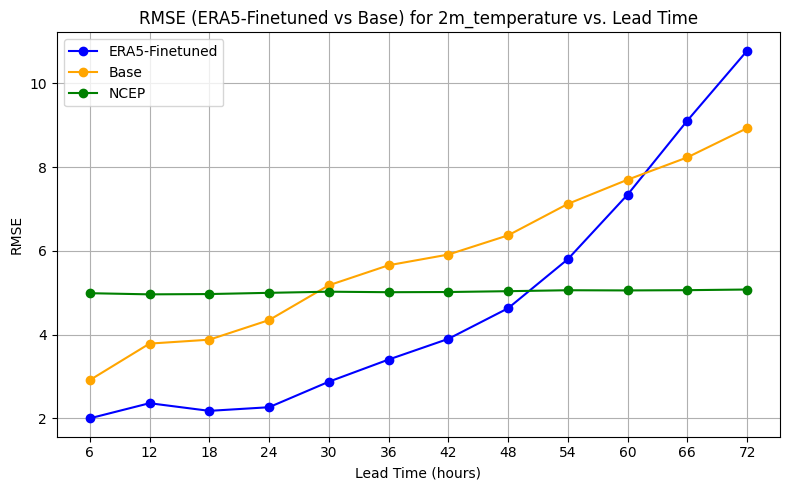

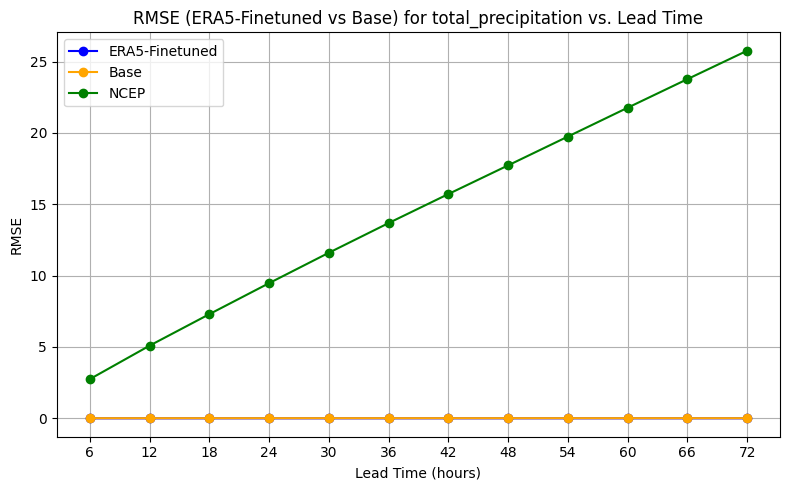

In [15]:
plot_error_vs_lead_time(groundtruth, predictions, base, ncep, label1='ERA5-Finetuned', label2='Base', label3='NCEP')

In [20]:
def compute_spatial_average(ds, variable_name, use_latitude_weights=True):
    """
    Computes the spatial average of a variable in an xarray.Dataset.
    """
    # print(ds)
    if use_latitude_weights:
        weights = np.cos(np.deg2rad(ds.latitude))
        weights = weights / weights.mean() 
        spatial_avg = ds[variable_name].weighted(weights).mean(dim=["latitude", "longitude"])
    else:
        spatial_avg = ds[variable_name].mean(dim=["latitude", "longitude"])
    return spatial_avg

def plot_interactive_forecast_comparison_ts(
    ground_truth_ds,
    forecast_datasets, 
    variable_name,
    use_latitude_weights_for_avg=True
):
    """
    Generates an interactive plot using ipywidgets and Plotly FigureWidget.
    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot.
        use_latitude_weights_for_avg (bool): Latitude weighting for spatial average.
    Returns:
        ipywidgets.VBox: A VBox containing the dropdown and the plot.
    """
    
    # Use FigureWidget for compatibility with ipywidgets
    fig_widget = go.FigureWidget()
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    ground_truth_ds = ground_truth_ds.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    for key, _ in forecast_datasets.items():
        forecast_datasets[key] = forecast_datasets[key].interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    
    # Process and plot ground truth 
    if 'step' in ground_truth_ds.coords and len(ground_truth_ds.step) > 0:
        reference_step = ground_truth_ds.step.min().item()
        reference_step = pd.to_timedelta(reference_step)
        gt_selected_step_ds = ground_truth_ds.sel(step=reference_step)
        gt_spatial_avg = compute_spatial_average(gt_selected_step_ds, variable_name, use_latitude_weights_for_avg)
        gt_x_values = gt_selected_step_ds.base_time.data + reference_step
        gt_y_values = gt_spatial_avg.data
    elif 'time' in ground_truth_ds.coords:
        gt_spatial_avg = compute_spatial_average(ground_truth_ds, variable_name, use_latitude_weights_for_avg)
        gt_x_values = gt_spatial_avg.time.data 
        gt_y_values = gt_spatial_avg.data
    else:
        raise ValueError("Ground truth dataset must have 'step' or 'time' coordinate.")

    fig_widget.add_trace(go.Scatter(
        x=gt_x_values,
        y=gt_y_values,
        mode='lines+markers',
        name='Ground Truth',
        line=dict(color='black', width=2, dash='dash')
    ))

    all_steps_values = np.array([])
    step_options_for_dropdown = []

    if forecast_datasets:
        first_forecast_name = list(forecast_datasets.keys())[0]
        if 'step' in forecast_datasets[first_forecast_name].coords:
            all_steps_values = np.sort(np.unique(forecast_datasets[first_forecast_name].step.data))
            step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]

    # Pre-calculate all spatial averages for forecasts
    precomputed_forecast_spatial_avgs = {}
    if forecast_datasets:
        for model_name, ds_forecast in forecast_datasets.items():
            precomputed_forecast_spatial_avgs[model_name] = compute_spatial_average(
                ds_forecast, variable_name, use_latitude_weights_for_avg
            )

    # Add initial traces for each forecast model (for the first step)
    initial_step_value = all_steps_values[0] if len(all_steps_values) > 0 else None
    
    forecast_traces_indices = [] # To keep track of which traces belong to forecasts
    
    for model_idx, (model_name, ds_forecast) in enumerate(forecast_datasets.items()):
        x_init, y_init = [], []
        if initial_step_value is not None and model_name in precomputed_forecast_spatial_avgs:
            forecast_spatial_avg = precomputed_forecast_spatial_avgs[model_name]
            selected_step_data_array = forecast_spatial_avg.sel(step=initial_step_value)
            valid_times_for_plot = selected_step_data_array.coords['base_time'].data + initial_step_value
            x_init = valid_times_for_plot
            y_init = selected_step_data_array.data
        
        fig_widget.add_trace(go.Scatter(
            x=x_init,
            y=y_init,
            mode='lines',
            name=f'{model_name}'
        ))
        forecast_traces_indices.append(model_idx + 1) # +1 because GT is trace 0

    # Create ipywidgets.Dropdown for step selection
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value if initial_step_value is not None else None,
        description='Lead Time:',
        disabled=not bool(step_options_for_dropdown) # Disable if no steps
    )

    # Define the function to update plot on dropdown change
    def update_plot_on_step_change(change):
        selected_step_val = change['new'] # The new value of the dropdown
        
        with fig_widget.batch_update(): # Efficiently update multiple traces
            for i, model_name_iter in enumerate(forecast_datasets.keys()):
                trace_idx = forecast_traces_indices[i] # Get the correct trace index
                if model_name_iter in precomputed_forecast_spatial_avgs:
                    forecast_spatial_avg = precomputed_forecast_spatial_avgs[model_name_iter]
                    
                    # Check if the selected step exists for this model's precomputed avg
                    if selected_step_val in forecast_spatial_avg.step.data:
                        selected_step_data_array = forecast_spatial_avg.sel(step=selected_step_val)
                        valid_times_for_plot = selected_step_data_array.coords['base_time'].data + selected_step_val
                        
                        fig_widget.data[trace_idx].x = valid_times_for_plot
                        fig_widget.data[trace_idx].y = selected_step_data_array.data
                    else: # If step not available (e.g. different models have different steps)
                        fig_widget.data[trace_idx].x = []
                        fig_widget.data[trace_idx].y = []
                else:
                    fig_widget.data[trace_idx].x = []
                    fig_widget.data[trace_idx].y = []

    step_dropdown.observe(update_plot_on_step_change, names='value')

    # Configure plot layout
    fig_title = f'Spatially Averaged {variable_name.replace("_", " ").title()} Comparison'
    yaxis_title = f'{variable_name.replace("_", " ").title()}'
    if variable_name == "2m_temperature":
        yaxis_title += " (K)"
    elif variable_name == "total_precipitation":
        yaxis_title += " (mm)"

    fig_widget.update_layout(
        title=fig_title,
        xaxis_title='Valid Time',
        yaxis_title=yaxis_title,
        legend_title_text='Legend',
        hovermode="x unified"
    )
    
    # Return a VBox containing the dropdown and the FigureWidget
    return widgets.VBox([step_dropdown, fig_widget])

In [21]:
def compute_spatial_average_of_field(field_da, use_latitude_weights=True):
    """
    Computes the spatial average of a DataArray (e.g., an error field).
    Assumes field_da has 'latitude' and 'longitude' dimensions.
    """
    if not field_da.chunks: # Ensure it's not a dask array without chunks for weighted
        field_da = field_da.compute() # Load into memory if it's a small result

    if use_latitude_weights:
        weights = np.cos(np.deg2rad(field_da.latitude))
        weights = weights / weights.mean() 
        # Ensure weights are aligned if field_da is chunked
        # weights = weights.chunk({'latitude': field_da.chunks['latitude']}) if field_da.chunks else weights
        spatial_avg = field_da.weighted(weights).mean(dim=["latitude", "longitude"])
    else:
        spatial_avg = field_da.mean(dim=["latitude", "longitude"])
    return spatial_avg

def plot_interactive_daily_error_comparison(
    ground_truth_ds,
    forecast_datasets, 
    variable_name,
    use_latitude_weights_for_avg=True
):
    """
    Generates an interactive plot of spatially averaged errors of daily maxima and minima 
    using ipywidgets and Plotly FigureWidget.
    Args:
        ground_truth_ds (xr.Dataset): Dataset for ground truth.
        forecast_datasets (dict): Dictionary of forecast datasets.
        variable_name (str): The variable to plot.
        use_latitude_weights_for_avg (bool): Latitude weighting for spatial average of errors.
    Returns:
        ipywidgets.VBox: A VBox containing the dropdown and the plot.
    """
    
    fig_widget = go.FigureWidget()
    new_lats = np.linspace(7.5, 37.5, 61)
    new_lons = np.linspace(67.5, 97.5, 61)
    ground_truth_ds = ground_truth_ds.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    for key, _ in forecast_datasets.items():
        forecast_datasets[key] = forecast_datasets[key].interp({'latitude': new_lats, 'longitude': new_lons}, 
                                    method='linear',
                                    kwargs={'fill_value': None})
    # --- Process Ground Truth: Get Gridded Daily Max/Min ---
    reference_step = pd.to_timedelta('0 hours') 
    if 'step' in ground_truth_ds.coords and len(ground_truth_ds.step) > 0:
        reference_step = pd.to_timedelta(ground_truth_ds.step.min().item())
        gt_data_at_ref_step = ground_truth_ds[variable_name].sel(step=reference_step)
    elif 'time' in ground_truth_ds.coords: # Observational data
        # Ensure 'time' coord is named 'base_time' for consistency with resample
        if 'base_time' not in ground_truth_ds[variable_name].coords:
            gt_data_at_ref_step = ground_truth_ds[variable_name].rename({'time': 'base_time'})
        else:
            gt_data_at_ref_step = ground_truth_ds[variable_name]
    else:
        raise ValueError("Ground truth dataset must have 'step' or 'time' coordinate.")

    # Resample GT to daily max/min at each grid point
    # The 'base_time' coordinate of these will be daily.
    gt_daily_max_gridded = gt_data_at_ref_step.resample(base_time="1D").max()
    gt_daily_min_gridded = gt_data_at_ref_step.resample(base_time="1D").min()

    # --- Pre-calculate Gridded Daily Max/Min for Forecasts ---
    precomputed_fcst_daily_max_gridded = {}
    precomputed_fcst_daily_min_gridded = {}
    
    all_steps_values = np.array([])
    if forecast_datasets:
        first_forecast_name = list(forecast_datasets.keys())[0] # Assume steps are consistent
        if 'step' in forecast_datasets[first_forecast_name].coords:
            all_steps_values = np.sort(np.unique(forecast_datasets[first_forecast_name].step.data))

        for model_name, ds_forecast in forecast_datasets.items():
            model_var_data = ds_forecast[variable_name] # This has (base_time, step, lat, lon)
            # Resample over base_time for each step, lat, lon to get daily values
            precomputed_fcst_daily_max_gridded[model_name] = model_var_data.resample(base_time="1D").max()
            precomputed_fcst_daily_min_gridded[model_name] = model_var_data.resample(base_time="1D").min()
    
    step_options_for_dropdown = [(f"{int(s / np.timedelta64(1, 'h'))} hr lead", s) for s in all_steps_values]

    # --- Add Initial Traces for Forecast Errors (Daily Max & Min MAE) ---
    initial_step_value = all_steps_values[0] if len(all_steps_values) > 0 else None
    
    # Store trace indices: each model will have a max error trace and a min error trace
    # e.g., { 'Model A': {'max_trace_idx': 0, 'min_trace_idx': 1}, ... }
    model_trace_indices = {} 
    current_trace_idx = 0

    if initial_step_value is not None:
        for model_name in forecast_datasets.keys():
            fcst_daily_max_at_step = precomputed_fcst_daily_max_gridded[model_name].sel(step=initial_step_value)
            fcst_daily_min_at_step = precomputed_fcst_daily_min_gridded[model_name].sel(step=initial_step_value)

            # Align with GT and calculate error (Xarray handles alignment based on coords)
            error_daily_max_gridded = fcst_daily_max_at_step - gt_daily_max_gridded
            error_daily_min_gridded = fcst_daily_min_at_step - gt_daily_min_gridded
            
            # Calculate Mean Absolute Error (MAE) time series
            mae_daily_max_ts = compute_spatial_average_of_field(np.abs(error_daily_max_gridded), use_latitude_weights_for_avg)
            mae_daily_min_ts = compute_spatial_average_of_field(np.abs(error_daily_min_gridded), use_latitude_weights_for_avg)
            
            # Valid times for the x-axis of the error plot
            # The base_time of mae_daily_max_ts is daily (from resample)
            # Add the selected step to get the valid time of the daily statistic
            x_plot_valid_time = mae_daily_max_ts.base_time.data + initial_step_value

            fig_widget.add_trace(go.Scatter(
                x=x_plot_valid_time, y=mae_daily_max_ts.data, mode='lines', 
                name=f'{model_name} (MAE Daily Max)'
            ))
            model_trace_indices[model_name] = {'max_trace_idx': current_trace_idx}
            current_trace_idx += 1

            fig_widget.add_trace(go.Scatter(
                x=x_plot_valid_time, y=mae_daily_min_ts.data, mode='lines', 
                name=f'{model_name} (MAE Daily Min)', line=dict(dash='dash')
            ))
            model_trace_indices[model_name]['min_trace_idx'] = current_trace_idx
            current_trace_idx += 1

    # --- Create ipywidgets.Dropdown for step selection ---
    step_dropdown = widgets.Dropdown(
        options=step_options_for_dropdown,
        value=initial_step_value,
        description='Lead Time:',
        disabled=not bool(step_options_for_dropdown)
    )

    # --- Define the function to update plot on dropdown change ---
    def update_plot_on_step_change(change):
        selected_step_val = change['new'] 
        
        with fig_widget.batch_update():
            for model_name in forecast_datasets.keys():
                if model_name not in precomputed_fcst_daily_max_gridded: continue

                fcst_daily_max_at_step = precomputed_fcst_daily_max_gridded[model_name].sel(step=selected_step_val)
                fcst_daily_min_at_step = precomputed_fcst_daily_min_gridded[model_name].sel(step=selected_step_val)

                error_daily_max_gridded = fcst_daily_max_at_step - gt_daily_max_gridded
                error_daily_min_gridded = fcst_daily_min_at_step - gt_daily_min_gridded
                
                mae_daily_max_ts = compute_spatial_average_of_field(np.abs(error_daily_max_gridded), use_latitude_weights_for_avg)
                mae_daily_min_ts = compute_spatial_average_of_field(np.abs(error_daily_min_gridded), use_latitude_weights_for_avg)
                
                x_plot_valid_time = mae_daily_max_ts.base_time.data + selected_step_val
                
                # Update traces
                max_idx = model_trace_indices[model_name]['max_trace_idx']
                min_idx = model_trace_indices[model_name]['min_trace_idx']

                fig_widget.data[max_idx].x = x_plot_valid_time
                fig_widget.data[max_idx].y = mae_daily_max_ts.data
                
                fig_widget.data[min_idx].x = x_plot_valid_time
                fig_widget.data[min_idx].y = mae_daily_min_ts.data
                
    step_dropdown.observe(update_plot_on_step_change, names='value')

    # --- Configure plot layout ---
    fig_title = f'Spatially Averaged MAE of Daily Max/Min {variable_name.replace("_", " ").title()}'
    yaxis_title = f'Mean Absolute Error ({variable_name.replace("_", " ").title()})'
    if variable_name == "2m_temperature":
        yaxis_title += " (K)"
    elif variable_name == "total_precipitation":
        yaxis_title += " (mm)" # Or appropriate unit for precipitation error

    fig_widget.update_layout(
        title=fig_title,
        xaxis_title='Valid Time of Daily Statistic',
        yaxis_title=yaxis_title,
        legend_title_text='Model Error',
        hovermode="x unified"
    )
    
    return widgets.VBox([step_dropdown, fig_widget])

In [22]:
plot_interactive_forecast_comparison_ts(groundtruth, {"gc-finetuned": predictions, "gc-base": base, "ncep":ncep}, '2m_temperature', False)

In [ ]:
plot_interactive_daily_error_comparison(tmax_data.rename({'base_time': 'time'}), {'era5': groundtruth, "gc-finetuned": predictions, "gc-base": base}, '2m_temperature', False)

In [ ]:
plot_interactive_daily_error_comparison(tmin_data.rename({'base_time': 'time'}), {'era5': groundtruth, "gc-finetuned": predictions, "gc-base": base, 'ncep': ncep}, '2m_temperature', False)